(20024, 20)


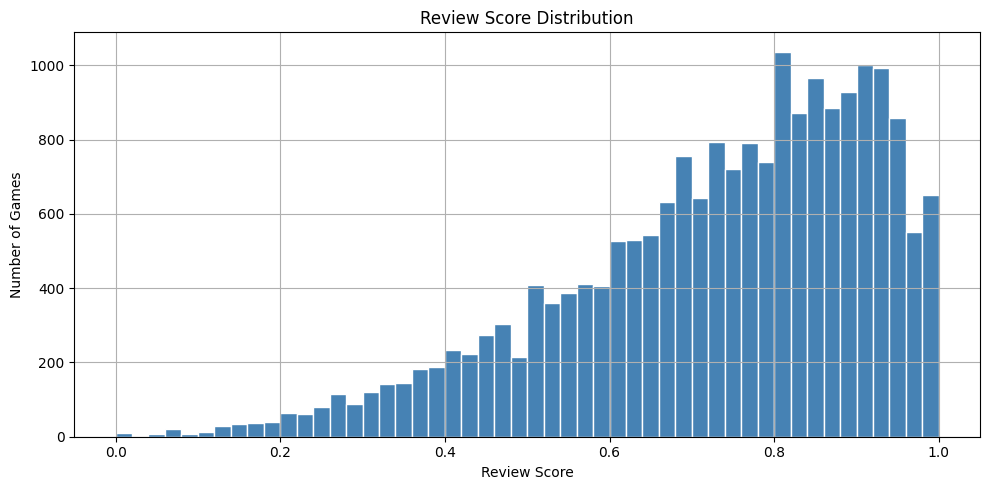

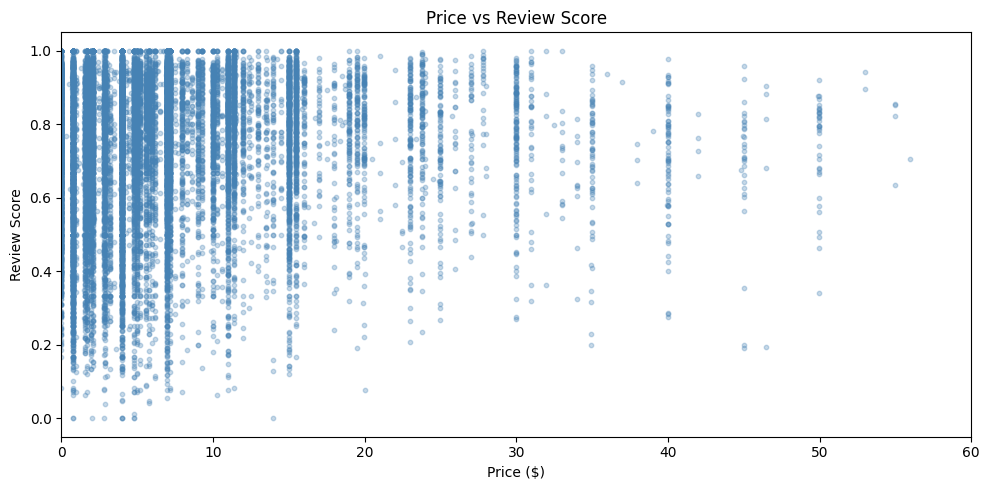

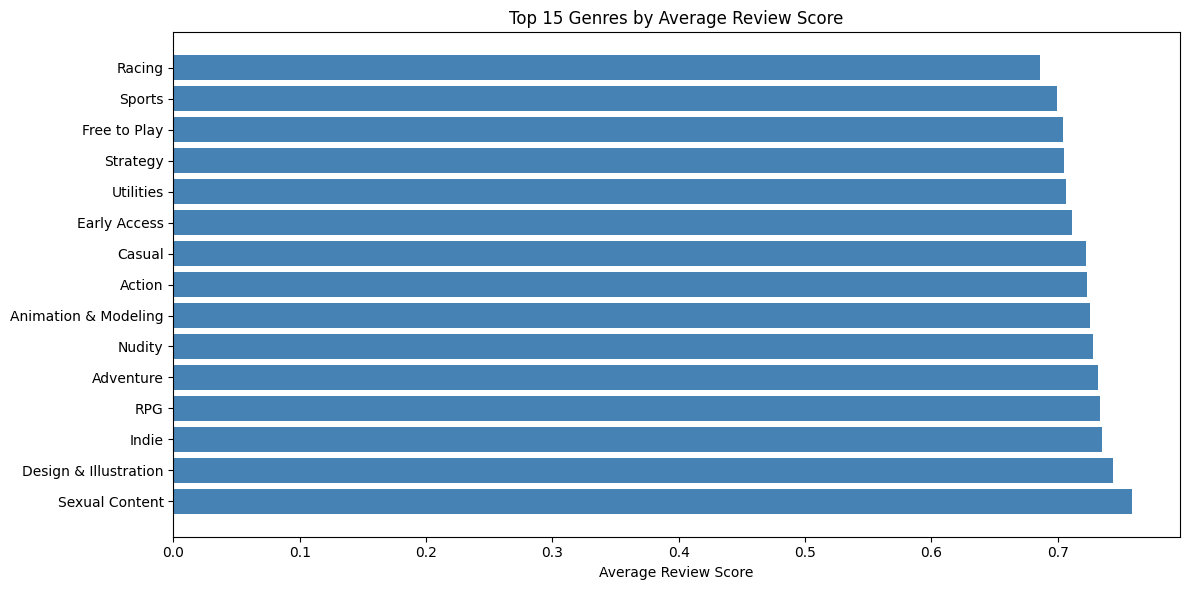

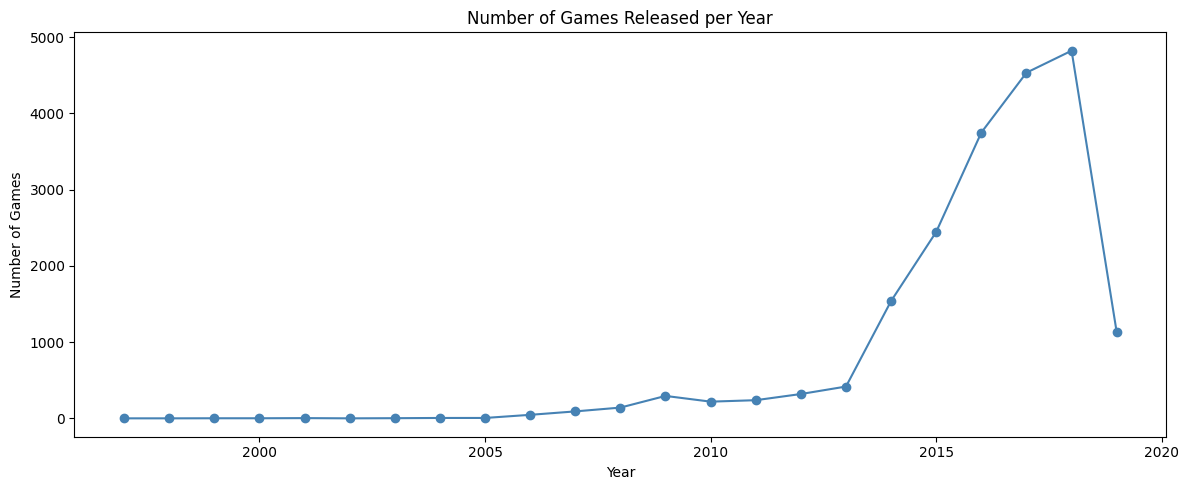

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/steam_clean.csv")
print(df.shape)


plt.figure(figsize=(10, 5))
df['review_score'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
plt.scatter(df['price'], df['review_score'], alpha=0.3, s=10, color='steelblue')
plt.title('Price vs Review Score')
plt.xlabel('Price ($)')
plt.ylabel('Review Score')
plt.xlim(0, 60)
plt.tight_layout()
plt.show()





# Split genres and explode into separate rows
genre_df = df.copy()
genre_df['genres'] = genre_df['genres'].str.split(';')
genre_df = genre_df.explode('genres')

# Get top 15 genres by average review score
top_genres = genre_df.groupby('genres')['review_score'].agg(['mean', 'count'])
top_genres = top_genres[top_genres['count'] > 50]  # only genres with enough games
top_genres = top_genres.sort_values('mean', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_genres.index, top_genres['mean'], color='steelblue')
plt.title('Top 15 Genres by Average Review Score')
plt.xlabel('Average Review Score')
plt.tight_layout()
plt.show()





releases_per_year = df.groupby('release_year').size()

plt.figure(figsize=(12, 5))
plt.plot(releases_per_year.index, releases_per_year.values, color='steelblue', marker='o')
plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()